In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
base = "../data/raw/"

fund_master = pd.read_csv(base + "01_fund_master.csv")
nav = pd.read_csv(base + "02_nav_history.csv")
aum = pd.read_csv(base + "03_aum_by_fund_house.csv")
sip = pd.read_csv(base + "04_monthly_sip_inflows.csv")
category = pd.read_csv(base + "05_category_inflows.csv")
folio = pd.read_csv(base + "06_industry_folio_count.csv")
performance = pd.read_csv(base + "07_scheme_performance.csv")
investor = pd.read_csv(base + "08_investor_transactions.csv")
portfolio = pd.read_csv(base + "09_portfolio_holdings.csv")
benchmark = pd.read_csv(base + "10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [5]:
print(aum.columns)
print(sip.columns)
print(category.columns)
print(folio.columns)
print(investor.columns)
print(portfolio.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
Index(['month', 'category', 'net_inflow_crore'], dtype='object')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


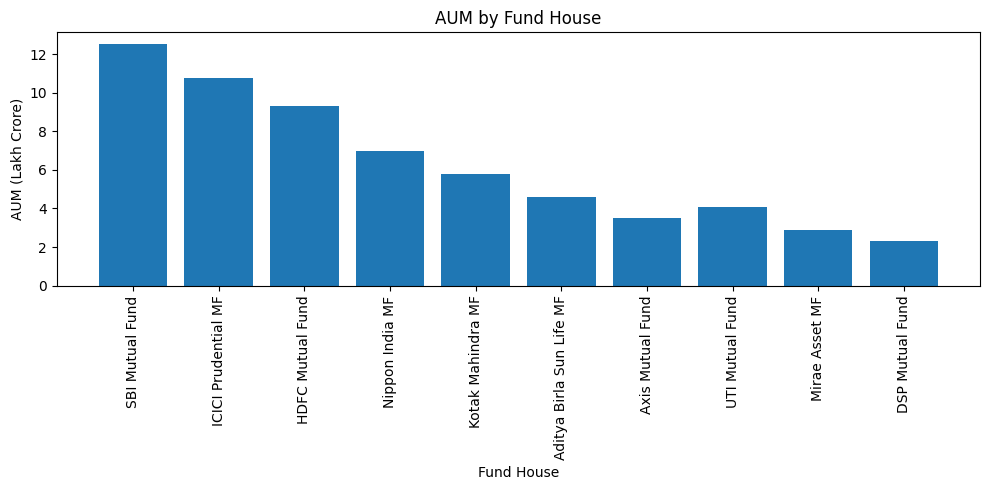

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    aum["fund_house"],
    aum["aum_lakh_crore"]
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")

plt.tight_layout()

plt.show()

In [16]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nFiles/Folders:")
print(os.listdir())

Current Directory:
d:\mutual-fund-analysis\notebooks

Files/Folders:
['EDA_Analysis.ipynb']


In [17]:
import os

print("Reports exists:", os.path.exists("reports"))
print("Charts exists:", os.path.exists("reports/charts"))
print("Parent reports exists:", os.path.exists("../reports"))
print("Parent charts exists:", os.path.exists("../reports/charts"))

Reports exists: False
Charts exists: False
Parent reports exists: True
Parent charts exists: True


In [18]:
plt.savefig("aum_growth.png")
plt.show()

<Figure size 640x480 with 0 Axes>

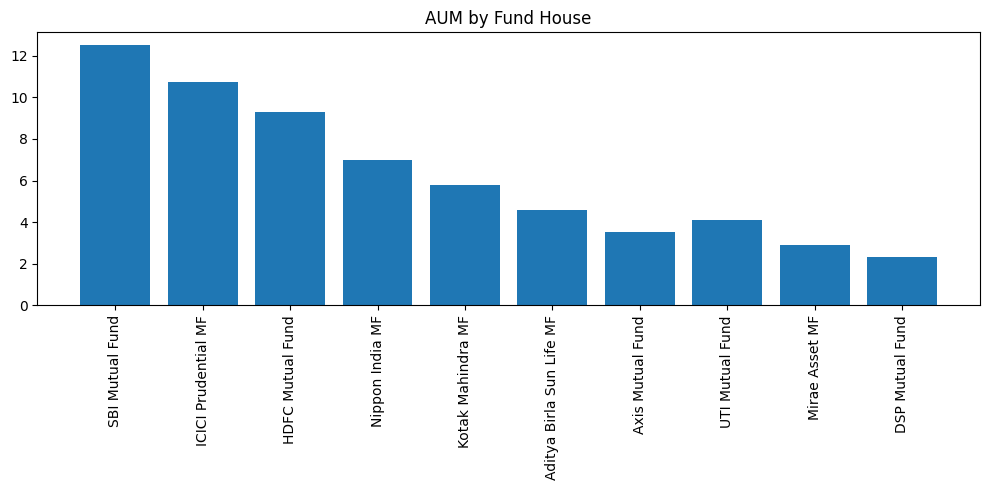

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    aum["fund_house"],
    aum["aum_lakh_crore"]
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.tight_layout()

plt.savefig("../reports/charts/aum_growth.png")

plt.show()

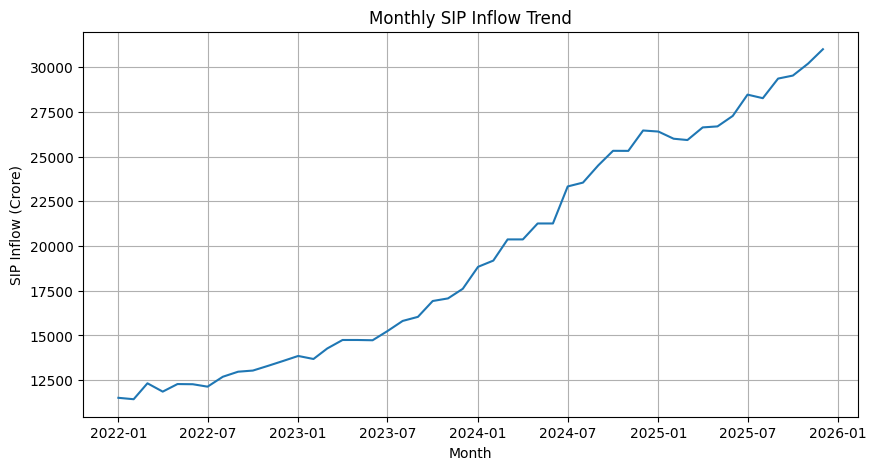

In [21]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(10,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")

plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.grid()

plt.show()

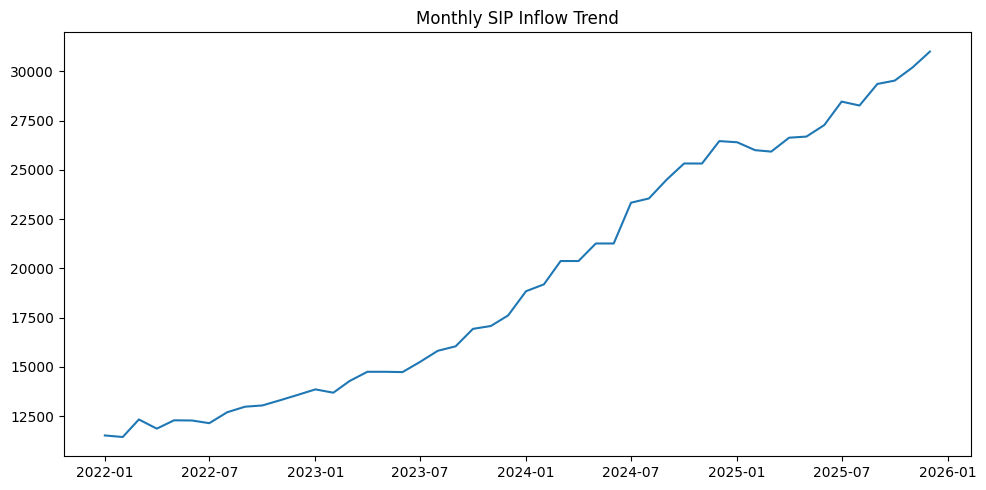

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")

plt.tight_layout()

plt.savefig("../reports/charts/sip_trend.png")

plt.show()

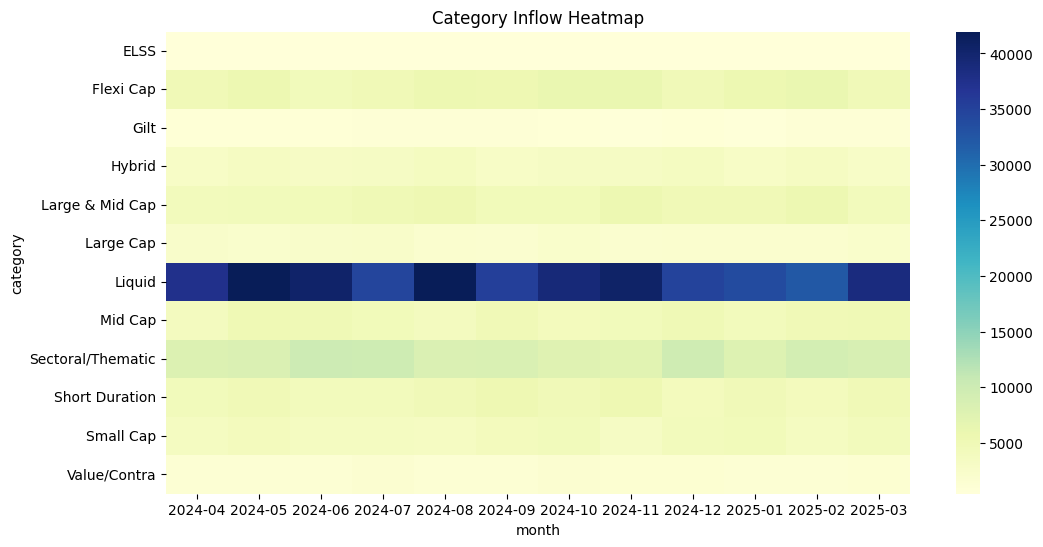

In [23]:
pivot_data = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

In [24]:
plt.savefig(r"D:\mutual-fund-analysis\reports\charts\category_heatmap.png")

<Figure size 640x480 with 0 Axes>

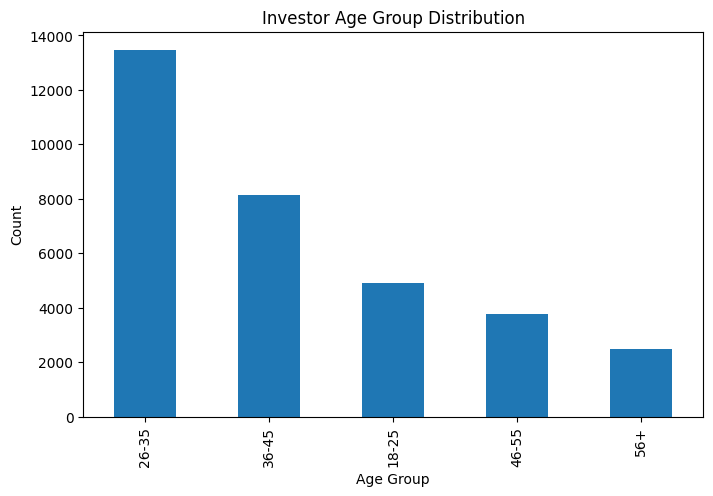

In [25]:
plt.figure(figsize=(8,5))

investor["age_group"].value_counts().plot(
    kind="bar"
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

In [26]:
plt.savefig(r"D:\mutual-fund-analysis\reports\charts\age_group_distribution.png")

<Figure size 640x480 with 0 Axes>

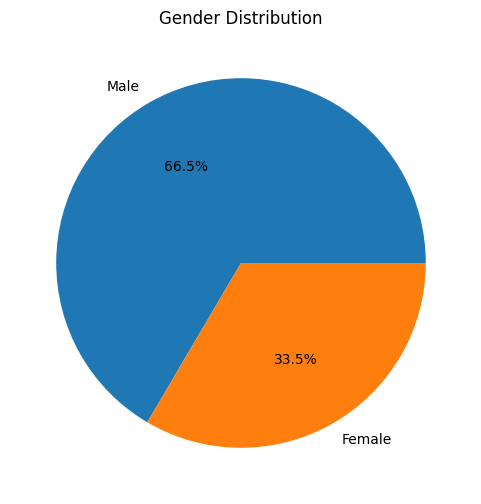

In [27]:
plt.figure(figsize=(6,6))

investor["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

In [28]:
plt.savefig(r"D:\mutual-fund-analysis\reports\charts\gender_distribution.png")

<Figure size 640x480 with 0 Axes>

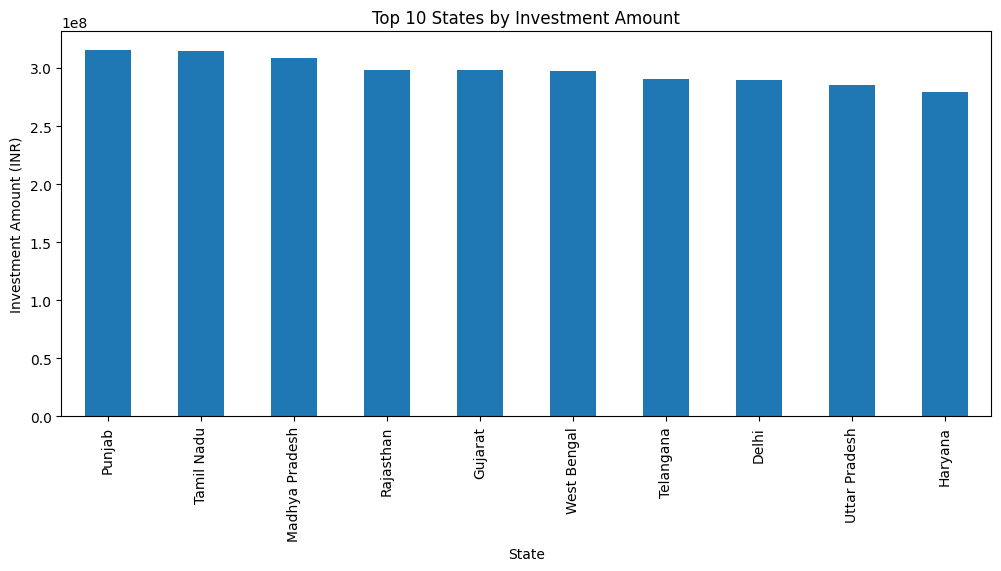

In [29]:
state_data = investor.groupby("state")["amount_inr"].sum()

plt.figure(figsize=(12,5))

state_data.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Investment Amount (INR)")

plt.show()

In [30]:
plt.savefig(r"D:\mutual-fund-analysis\reports\charts\state_investment.png")

<Figure size 640x480 with 0 Axes>

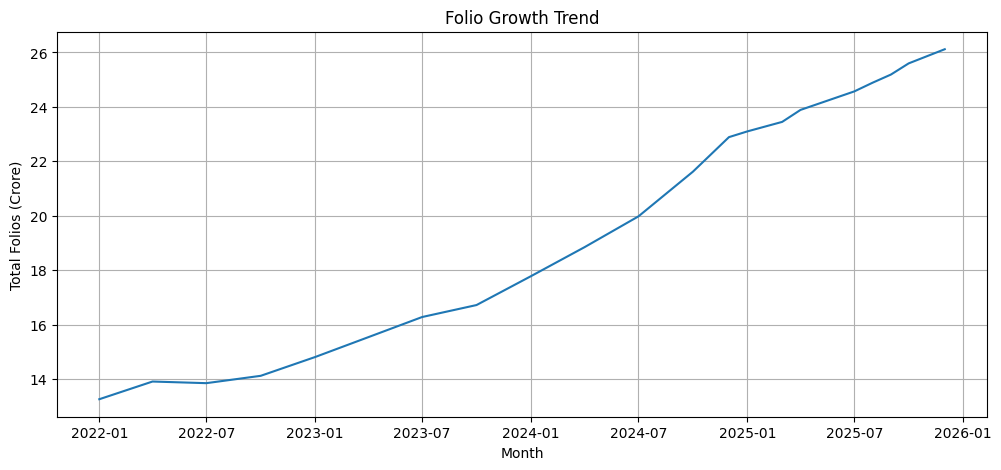

In [31]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Folio Growth Trend")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid()

plt.show()

In [32]:
plt.savefig(r"D:\mutual-fund-analysis\reports\charts\folio_growth.png")

<Figure size 640x480 with 0 Axes>

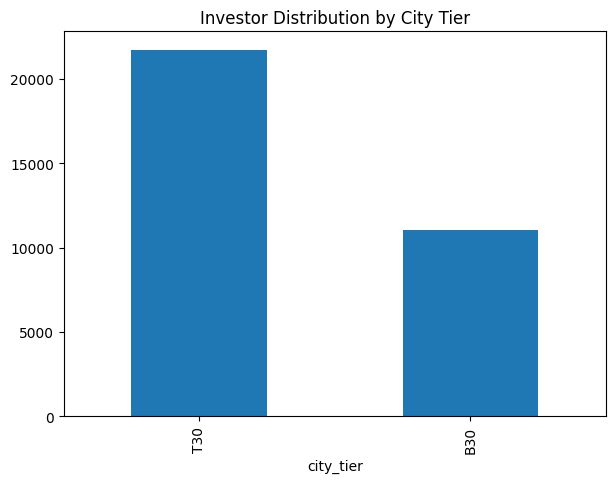

In [33]:
plt.figure(figsize=(7,5))

investor["city_tier"].value_counts().plot(
    kind="bar"
)

plt.title("Investor Distribution by City Tier")

plt.show()

In [34]:
plt.savefig(r"D:\mutual-fund-analysis\reports\charts\city_tier_distribution.png")

<Figure size 640x480 with 0 Axes>

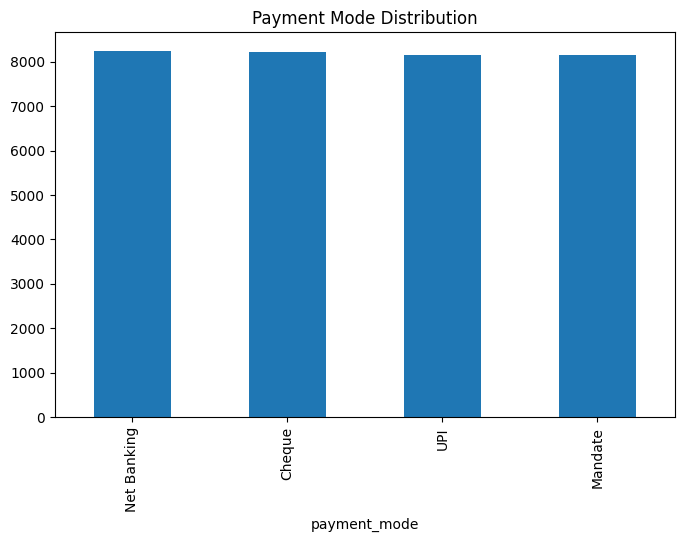

In [35]:
plt.figure(figsize=(8,5))
investor["payment_mode"].value_counts().plot(kind="bar")
plt.title("Payment Mode Distribution")
plt.show()

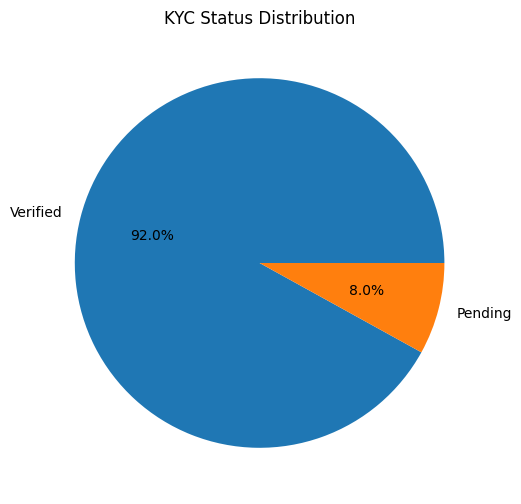

In [39]:
plt.figure(figsize=(6,6))
investor["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("KYC Status Distribution")
plt.ylabel("")
plt.show()

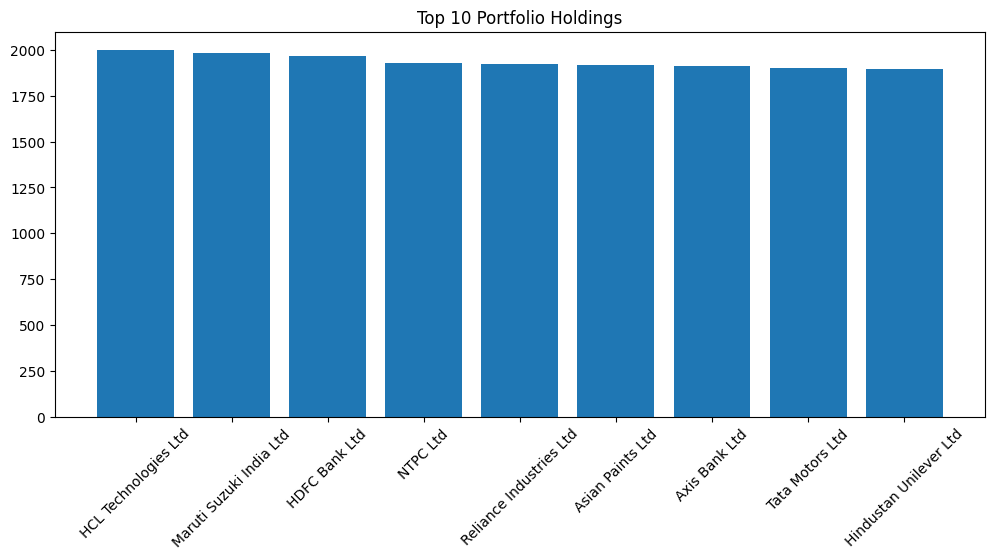

In [40]:
top_holdings = portfolio.sort_values(
    "market_value_cr",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))
plt.bar(
    top_holdings["stock_name"],
    top_holdings["market_value_cr"]
)
plt.xticks(rotation=45)
plt.title("Top 10 Portfolio Holdings")
plt.show()

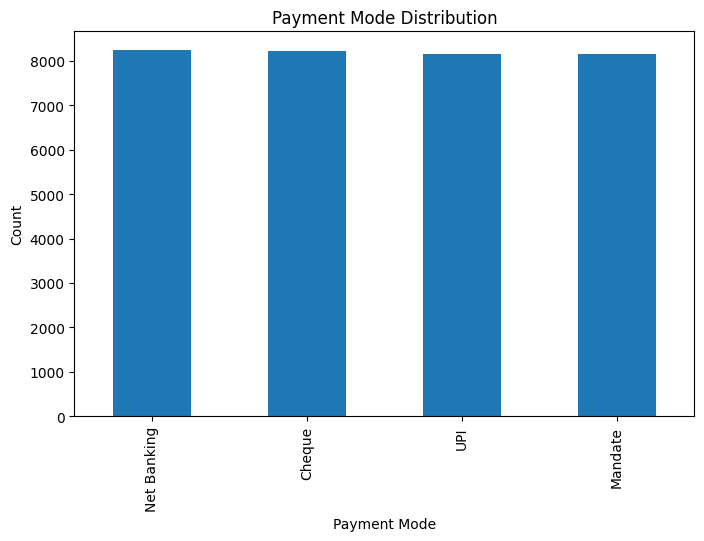

In [41]:
plt.figure(figsize=(8,5))

investor["payment_mode"].value_counts().plot(kind="bar")

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Count")

plt.savefig(r"D:\mutual-fund-analysis\reports\charts\payment_mode_distribution.png")
plt.show()

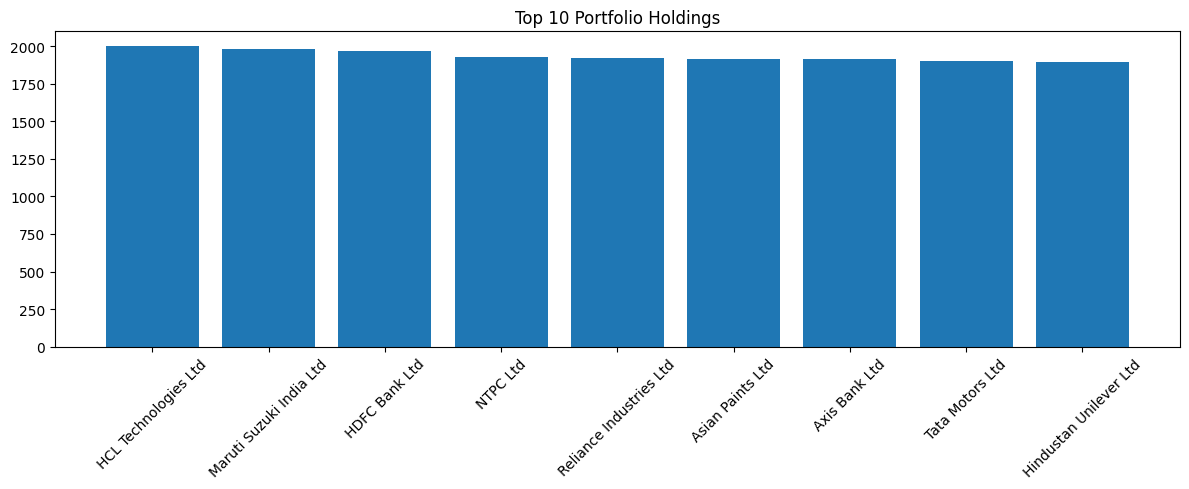

In [42]:
top_holdings = portfolio.sort_values(
    "market_value_cr",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top_holdings["stock_name"],
    top_holdings["market_value_cr"]
)

plt.xticks(rotation=45)
plt.title("Top 10 Portfolio Holdings")

plt.tight_layout()

plt.savefig(r"D:\mutual-fund-analysis\reports\charts\top_holdings.png")
plt.show()

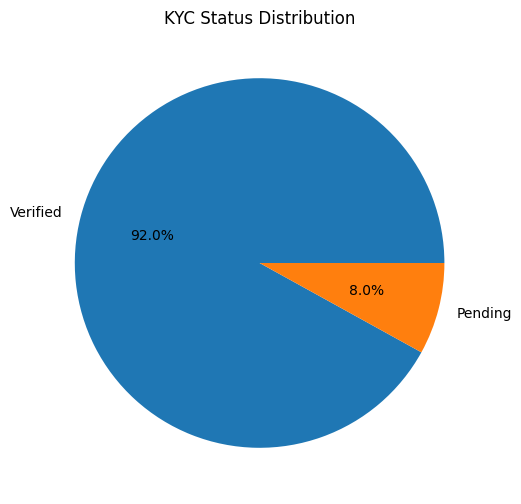

In [43]:
plt.figure(figsize=(6,6))

investor["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("KYC Status Distribution")
plt.ylabel("")

plt.savefig(r"D:\mutual-fund-analysis\reports\charts\kyc_status_distribution.png")
plt.show()